In [24]:
from qsopt import * 
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import jax
import qutip

from qsopt.core.gates import RYGate, RXGate
from qsopt.core.circuit import QuantumCircuit

print(f"JAX version: {jax.__version__}")
print(f"QuTiP version: {qutip.__version__}")

JAX version: 0.4.35
QuTiP version: 5.2.2


## Define experimental parameters

In [25]:
gm = 0.03 * 2 * np.pi
inverse_pulse_width = 0.1 * gm

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = 0.1 * gm      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times = None,  # Use default measurement times
    initial_time=-8.0/inverse_pulse_width,
    final_time=8.0/inverse_pulse_width,
    time_interval=4.0/inverse_pulse_width,
    initial_time_uncertainty=.0/inverse_pulse_width
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.0001,  
    dephasing = 0.0001,      
    relaxation = 0.0001
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Number of qubits:          1
  Cavity levels:             2
  Qubit levels:         [2]
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                  [0.09424777960769379]
  Photon cavity coupling: 0.1885
  Inverse pulse width:    0.0188
  Qubit interactions:   None
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      5
  Measurement times:    [-424.4131815783876, -212.2065907891938, 0.0, 212.2065907891938, 424.4131815783876]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0001]
  Dephasing rate:       [0.0001]
  Relaxation rate:      [0.0001]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## Optional, plot pulse shape

Pulse shape plot saved to: results/pulse_shape.png


C:\Users\simon\AppData\Local\Temp\ipykernel_25040\2894009835.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


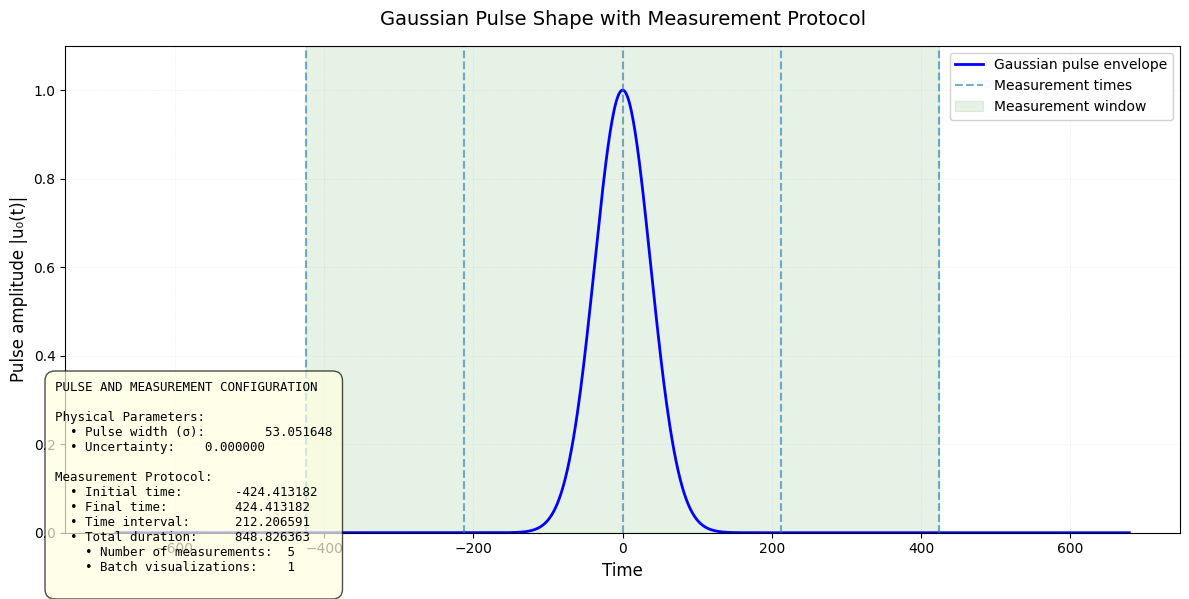

In [26]:
from qsopt.utils.visualization import plot_pulse_shape_with_measurements

fig = plot_pulse_shape_with_measurements(
    exp_params=exp_parameters,
    save_path='results/pulse_shape.png',
    batch_size=1
)
fig.show()

## Define quantum circuits

The new interface uses `QuantumCircuit` objects to define the gates applied before and after evolution. 

For the default RY protocol, we can simply use `None` (will auto-create RY circuits) or explicitly create them:

In [27]:
from qsopt.core.circuit import create_ry_circuit_layer
initial_circuit = create_ry_circuit_layer(n_qubits=1, theta_values=[np.pi/2])
final_circuit = create_ry_circuit_layer(n_qubits=1, theta_values=[-np.pi/2])

# The circuits contain trainable parameters that will be optimized
print(f"Initial circuit parameters: {initial_circuit.get_trainable_parameters()}")
print(f"Final circuit parameters: {final_circuit.get_trainable_parameters()}")

Initial circuit parameters: [Array(1.57079633, dtype=float64)]
Final circuit parameters: [Array(-1.57079633, dtype=float64)]


## Define experiment

In [28]:
experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
)

## Test Single Simulation

In [45]:
results = experiment.run_simulation()
print(results)

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
  Detection Probabilities:
     P(with photon):    0.976697
     P(without photon): 0.288511
     Contrast:          0.688186


## Time Evolution

In [30]:
result = experiment.time_evolution(n_points=300, with_interaction=True)
print(result)

from qsopt.utils.visualization import plot_time_evolution
plot_time_evolution(
    evolution_data=result,
    show_pulse=True,
    show_measurements=True,
    show_cavity_population=True,  # Cavity population (purple)
    show_field_population=True,   # External field population (brown)
    title='Single Qubit Evolution',
    figsize=(10, 6)
)
plt.show()

TypeError: float() argument must be a string or a real number, not 'list'

## Run Optimization

In [36]:
import optax

# The experiment automatically uses its built-in callback (saves every epoch by default)
history = experiment.optimize_rotations(
    initial_values=[1.3, -1.3],
    num_steps=100,
    verbose=True,
    verbose_step=20,
    batch_size=1,
    tolerance=1e-7,
    optimizer=optax.sgd(learning_rate=0.01)
)

Configuration:
    Max iterations: 100
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection criterion: 1 - P(0)
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0. setup_=1.300 rad (74.5°)
        param1. reset_=-1.300 rad (-74.5°)
Step  setup_0     reset_0     Contrast    Grad Norm
---------------------------------------------------------------------------
0     1.300000    -1.300000   0.687561    5.48e-02    
20    1.300749    -1.292842   0.687838    2.55e-02    
40    1.298665    -1.288761   0.687944    2.16e-02    
60    1.295946    -1.285548   0.688033    2.06e-02    
80    1.293150    -1.282637   0.688114    1.98e-02    
Final gradient norm: 1.90e-02
Best sensing contrast: 0.688186
Best parameters:
    param0. setup_[name]=1.291 rad (73.9°)
    param1. reset_[name]=-1.280 rad (-73.3°)


In [37]:
print(history)

MODE: Optimization
     Total iterations: 100
     Best epoch:        100
     Converged: False
     Final gradient norm: 1.903086e-02
  Best Parameters:
     Initial circuit:
        param_0: 1.290551 rad (73.94°)
     Final circuit:
        param_0: -1.280020 rad (-73.34°)
  Detection Probabilities:
     P(with photon):    0.976697
     P(without photon): 0.288511
     Contrast:          0.688186


## Visualization Dashboard

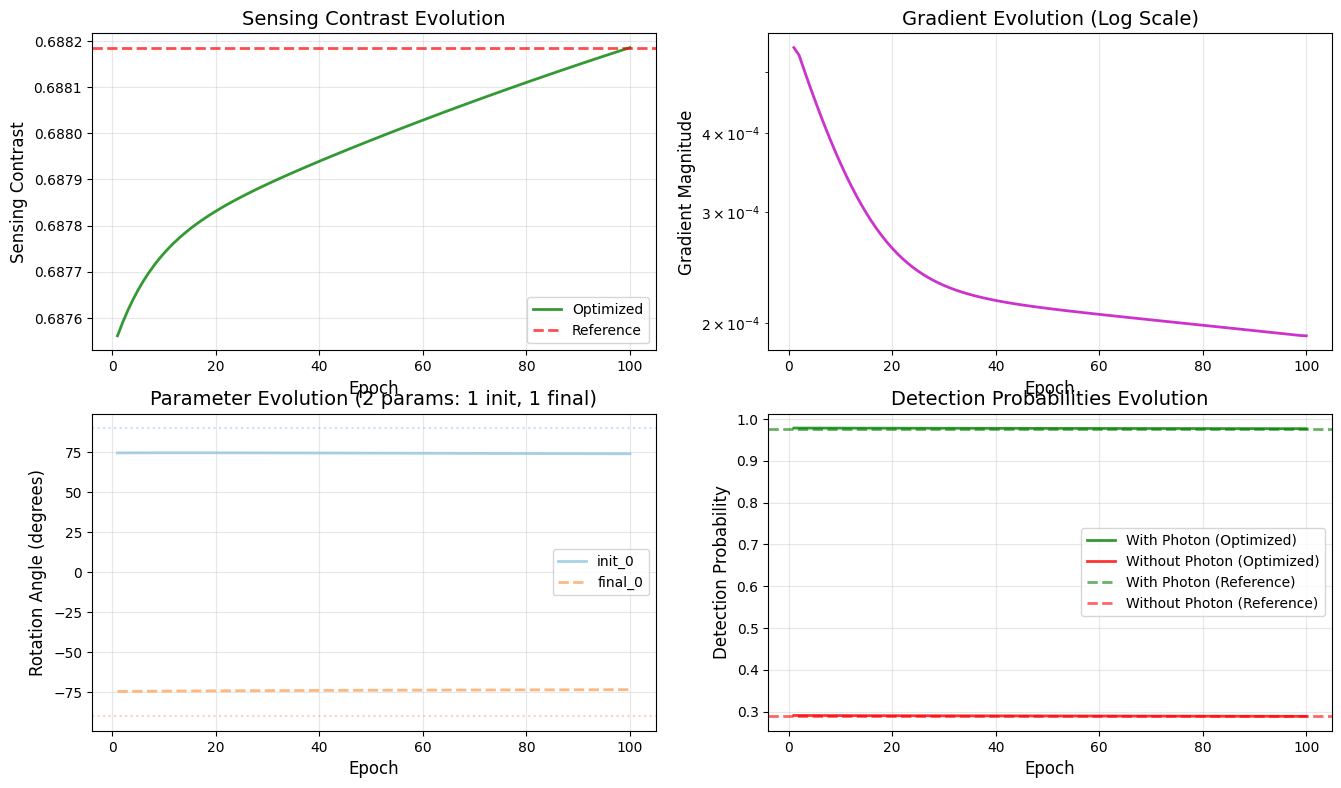

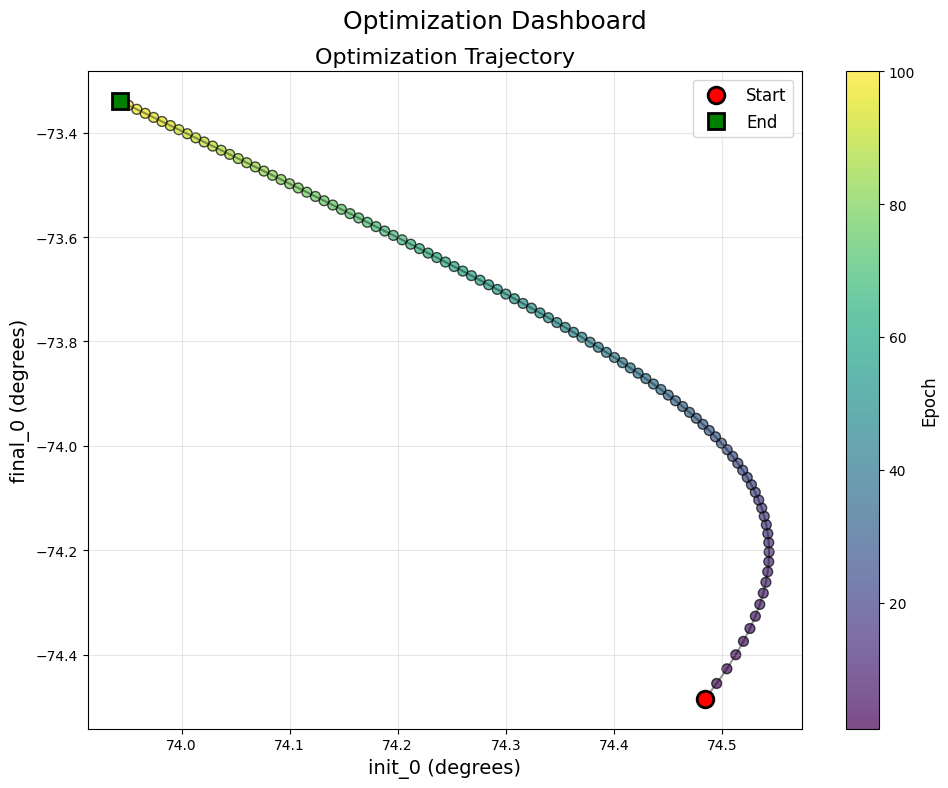

In [46]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_probabilities=True,
    save_path='results/rotations_opt_dashboard.pdf'  # Save to file
)

plt.show()

## Optimize Measurement Times

In [20]:
time_callback = experiment.optimize_measurement_times(batch_size=10, mode='discrete', verbose=True)

AttributeError: 'Experiment' object has no attribute 'optimize_measurement_times'

Time interval landscape plot saved to: results/time_interval_opt.pdf


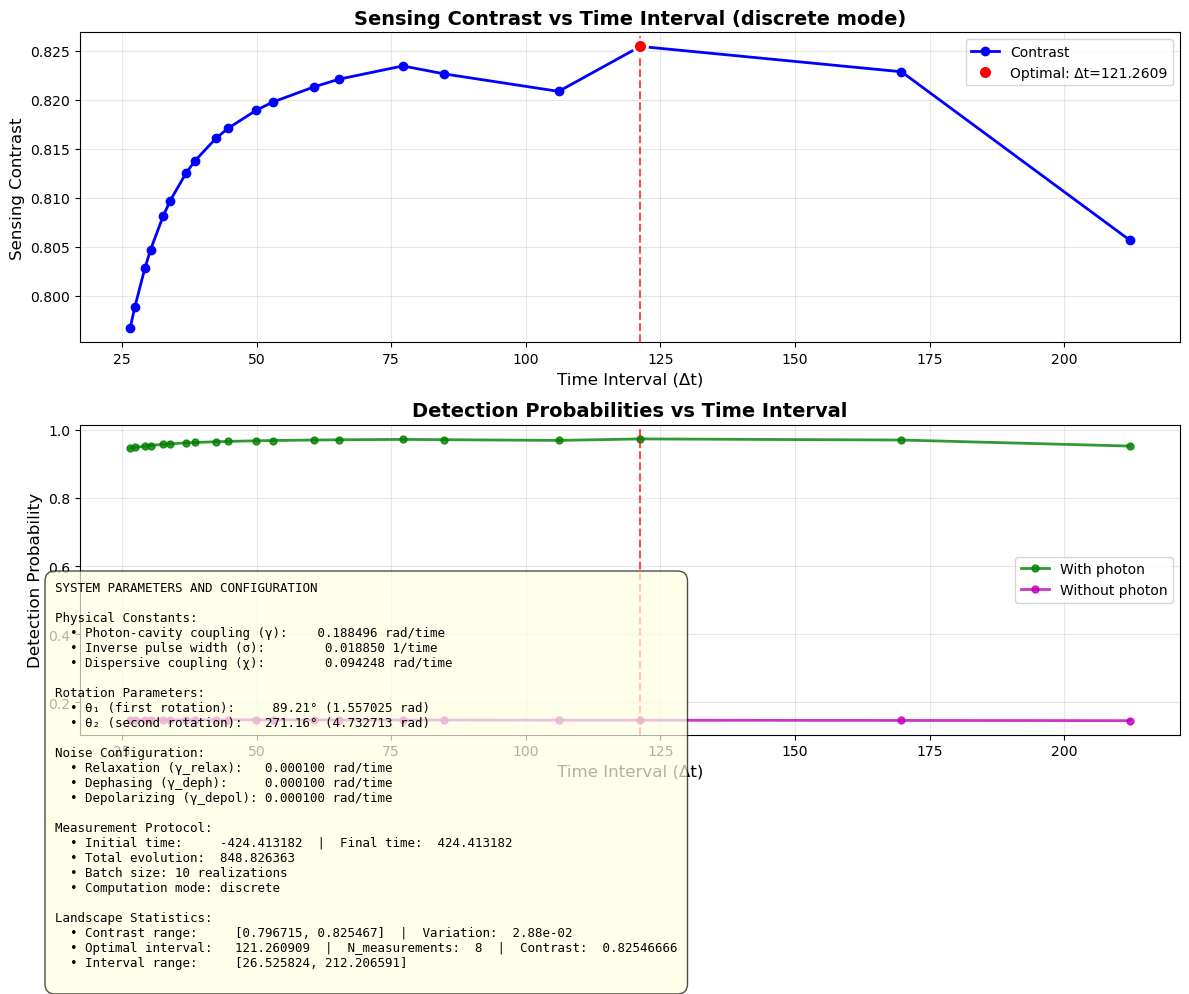

In [ ]:
from qsopt.utils.visualization import plot_time_interval_landscape

fig = plot_time_interval_landscape(
    landscape_data=time_callback,
    exp_params=experiment.experimental_params,
    save_path='results/time_interval_opt.pdf'
)


In [ ]:
# When using more measurements reduce the rotation optimizer learning rate
history = experiment.optimize_rotations(
    theta_init=[1.558, 4.734],
    num_steps=30,
    verbose=True,
    batch_size=10,
    tolerance=1e-7,
    verbose_step=10,
    optimizer=optax.sgd(0.05)
)

Configuration:
    Max iterations: 30
    Batch size: 10
    Convergence tolerance: 1.00e-07
    Initial rotation parameters: ry1=1.558 rad, ry2=4.734 rad
    Measurement interval parameters:
        interval=121.260909
Step  ry1         ry2         Contrast    Grad Norm
----------------------------------------------------------------------
0     1.558000    4.734000    0.825452    1.44e-02    
1     1.556818    4.733186    0.825467    6.52e-03    
2     1.556220    4.732927    0.825470    3.42e-03    
3     1.555880    4.732900    0.825471    2.33e-03    
4     1.555656    4.732965    0.825471    1.94e-03    
5     1.555489    4.733064    0.825472    1.75e-03    
6     1.555352    4.733173    0.825472    1.61e-03    
7     1.555232    4.733280    0.825472    1.48e-03    
8     1.555125    4.733382    0.825473    1.36e-03    
9     1.555027    4.733477    0.825473    1.26e-03    
10    1.554938    4.733565    0.825473    1.16e-03    
11    1.554856    4.733647    0.825473    1.07e-03  